Ethan Ho  
CMPE 256  
3/30/26  
Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
import keras
from keras import layers
import tensorflow as tf
from keras.models import Model
from keras.optimizers import Adam
from keras.layers import Add, Activation, Lambda, BatchNormalization, Concatenate, Dropout, Input, Embedding, Dot, Reshape, Dense, Flatten

In [ ]:
df = pd.read_csv("train.csv")
df.head()

,user_id,song_id,rating
0,1257279,1133436,4.25
1,1521617,1041044,2.75
2,1757741,1018376,4.25
3,1311545,1035650,5.25
4,1633733,1080634,8.25


In [ ]:
df.isnull().sum()

user_id    0
song_id    0
rating     0
dtype: int64

In [ ]:
df.tail()

,user_id,song_id,rating
5318224,1259514,1052552,5.50
5318225,1124783,1003187,5.00
5318226,1109277,1060261,7.00
5318227,1296363,1049236,5.00
5318228,1358156,1055568,8.25


Because only the last row has NaNs I remove them with iloc

In [ ]:
df = df.iloc[:-1]

In [ ]:
df.describe()

,user_id,song_id,rating
count,5.318228e+06,5.318228e+06,5.318228e+06
mean,1.395166e+06,1.023616e+06,5.370003e+00
std,2.285530e+05,3.301977e+04,1.732452e+00
min,1.000000e+06,1.000000e+06,1.000000e+00
25%,1.196543e+06,1.002793e+06,4.000000e+00
50%,1.395531e+06,1.010132e+06,4.750000e+00
75%,1.593041e+06,1.029929e+06,6.250000e+00
max,1.791700e+06,1.198134e+06,1.000000e+01


In [ ]:
df.describe()

,user_id,song_id,rating
count,5.318228e+06,5.318228e+06,5.318228e+06
mean,1.395166e+06,1.023616e+06,5.370003e+00
std,2.285530e+05,3.301977e+04,1.732452e+00
min,1.000000e+06,1.000000e+06,1.000000e+00
25%,1.196543e+06,1.002793e+06,4.000000e+00
50%,1.395531e+06,1.010132e+06,4.750000e+00
75%,1.593041e+06,1.029929e+06,6.250000e+00
max,1.791700e+06,1.198134e+06,1.000000e+01


<Axes: >

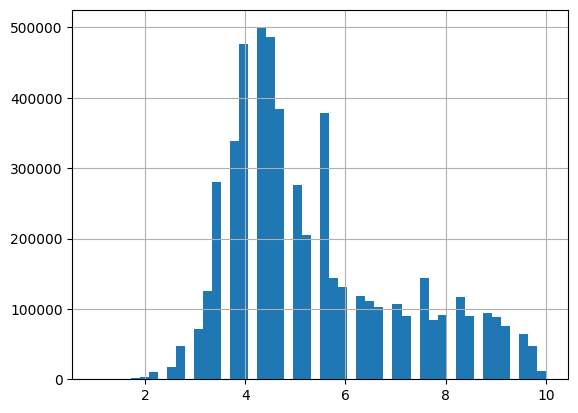

In [ ]:
df["rating"].hist(bins=50)

In [ ]:
user_counts = df.groupby("user_id").size()
user_counts.describe()

count    755694.000000
mean          7.037542
std           8.753179
min           1.000000
25%           2.000000
50%           4.000000
75%           9.000000
max         297.000000
dtype: float64

<Axes: >

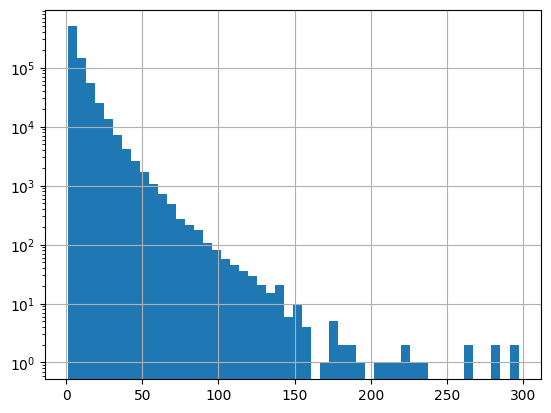

In [ ]:
user_counts.hist(log=True, bins=50)

<Axes: >

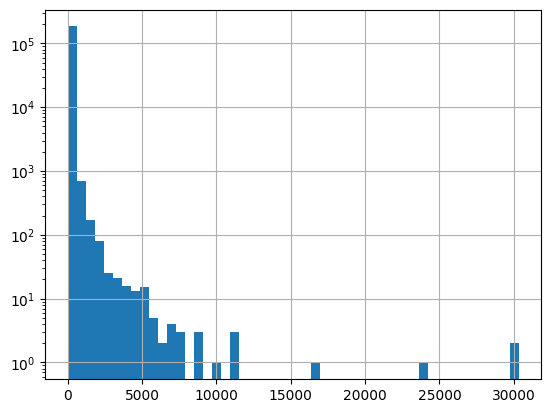

In [ ]:
song_counts = df.groupby("song_id").size()
song_counts.describe()
song_counts.hist(log=True, bins=50)

We can see that most songs are rated fairly so with a few popular ones rated a lot.

In [ ]:
num_users = df["user_id"].nunique()
num_songs = df["song_id"].nunique()
num_interactions = len(df)

sparsity = 1 - (num_interactions / (num_users * num_songs))
print(sparsity)

0.9999620852751638


<Axes: >

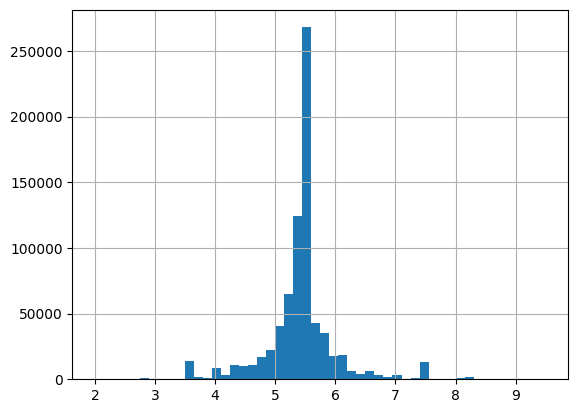

In [ ]:
user_mean_ratings = df.groupby("user_id")["rating"].mean()
user_mean_ratings.hist(bins=50)

I think a sensible eda step to take would be normalizing the user mean just for the matrix factorization. Later when we try the collaborative filtering, we will have the pearson similarity so for now I will make it into a seperate column

In [ ]:
df["rating_normalized"] = df["rating"] - df.groupby("user_id")["rating"].transform("mean")
df.head()

,user_id,song_id,rating,rating_normalized
0,1257279,1133436,4.25,-0.790323
1,1521617,1041044,2.75,-2.535714
2,1757741,1018376,4.25,-1.305556
3,1311545,1035650,5.25,-0.173077
4,1633733,1080634,8.25,2.951923


In [ ]:
x, y = df[["user_id", "song_id"]].values, df["rating_normalized"]

In [ ]:
# Checking for null values
print(y.isnull().sum())

0


I ran the song recommender file with the eda but ended up getting a worse score so I decided to go without it in the final run